# Data Exploration

In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading in the data

In [223]:
data = pd.read_csv('/Users/christianmonsalve/Desktop/CODE/Projects/Movie_Recs/data/processed/movies_cleaned.csv')

### Basic Data Inspection

In [224]:
data.head()

,tconst,titleType,primaryTitle,originalTitle,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,1894,2014,45,Romance,5.2,232.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897,2014,100,"Documentary,News,Sport",5.3,584.0
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,1900,2014,40,"Biography,Drama",5.4,67.0
3,tt0000502,movie,Bohemios,Bohemios,1905,2014,100,Unknown,3.1,26.0
4,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,2014,70,"Action,Adventure,Biography",6.0,1047.0


In [225]:
data.tail()

,tconst,titleType,primaryTitle,originalTitle,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
737030,tt9916622,movie,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,2014,57,Documentary,NaN,NaN
737031,tt9916680,movie,De la ilusión al desconcierto: cine colombiano...,De la ilusión al desconcierto: cine colombiano...,2007,2014,100,Documentary,NaN,NaN
737032,tt9916706,movie,Dankyavar Danka,Dankyavar Danka,2013,2014,30,Comedy,7.7,9.0
737033,tt9916730,movie,6 Gunn,6 Gunn,2017,2014,116,Drama,7.0,14.0
737034,tt9916754,movie,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,2014,49,Documentary,NaN,NaN


In [226]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737035 entries, 0 to 737034
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          737035 non-null  object 
 1   titleType       737035 non-null  object 
 2   primaryTitle    737035 non-null  object 
 3   originalTitle   737035 non-null  object 
 4   startYear       737035 non-null  int64  
 5   endYear         737035 non-null  int64  
 6   runtimeMinutes  737035 non-null  int64  
 7   genres          737035 non-null  object 
 8   averageRating   338186 non-null  float64
 9   numVotes        338186 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 56.2+ MB


In [227]:
description = data.describe()

def format_description(df):
    df = df.copy()
    cols = list(df.columns)
    for col in cols:
        df[col] = round(df[col], ndigits=2)

    return df
        
formatted_description = format_description(description)

In [228]:
formatted_description

,startYear,endYear,runtimeMinutes,averageRating,numVotes
count,737035.00,737035.0,737035.00,338186.00,338186.00
mean,1997.42,2014.0,67.73,6.17,3694.45
std,28.59,0.0,119.91,1.38,37576.31
min,1894.00,2014.0,1.00,1.00,5.00
25%,1984.00,2014.0,30.00,5.30,20.00
50%,2012.00,2014.0,69.00,6.30,64.00
75%,2016.00,2014.0,92.00,7.10,325.00
max,2031.00,2014.0,59460.00,10.00,3145376.00


### Double check duplicates and missing values

In [229]:
print("Duplicates: ", data.duplicated().sum())
print("Missing values: ", data.isnull().any(axis=1).sum())

Duplicates:  0
Missing values:  398849


In [230]:
data.loc[data.isnull().any(axis=1), :].sample()

,tconst,titleType,primaryTitle,originalTitle,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
191657,tt0393315,movie,Ganba,Ganba,1961,2014,30,Comedy,NaN,NaN


In [231]:
data['numVotes'] = data['numVotes'].fillna(0)
data['averageRating'] = data['averageRating'].fillna(round(data['averageRating'].mean(), 1))

In [232]:
data.iloc[550969]

tconst                               tt3552190
titleType                                movie
primaryTitle      Ferramonti: Il campo sospeso
originalTitle     Ferramonti: Il campo sospeso
startYear                                 2013
endYear                                   2014
runtimeMinutes                              30
genres                             Documentary
averageRating                              6.2
numVotes                                   0.0
Name: 550969, dtype: object

In [233]:
print("Missing values: ", data.isnull().any(axis=1).sum())

Missing values:  0


## Deeper Analysis

In [234]:
# All genres listed in our data
possible_genres = list(data['genres'].unique())
genres = set()

for genre in possible_genres:
    for g in genre.split(','):
        genres.add(g)

genres = list(genres)

In [235]:
print("Number of genres in our data: ", len(genres))
print("Genres:\n", genres)

Number of genres in our data:  29
Genres:
 ['Horror', 'Romance', 'Family', 'Documentary', 'Drama', 'Game-Show', 'Mystery', 'Adult', 'Western', 'War', 'Crime', 'Adventure', 'Biography', 'Film-Noir', 'Reality-TV', 'Unknown', 'History', 'Animation', 'News', 'Sci-Fi', 'Thriller', 'Fantasy', 'Music', 'Talk-Show', 'Sport', 'Comedy', 'Short', 'Musical', 'Action']


[]

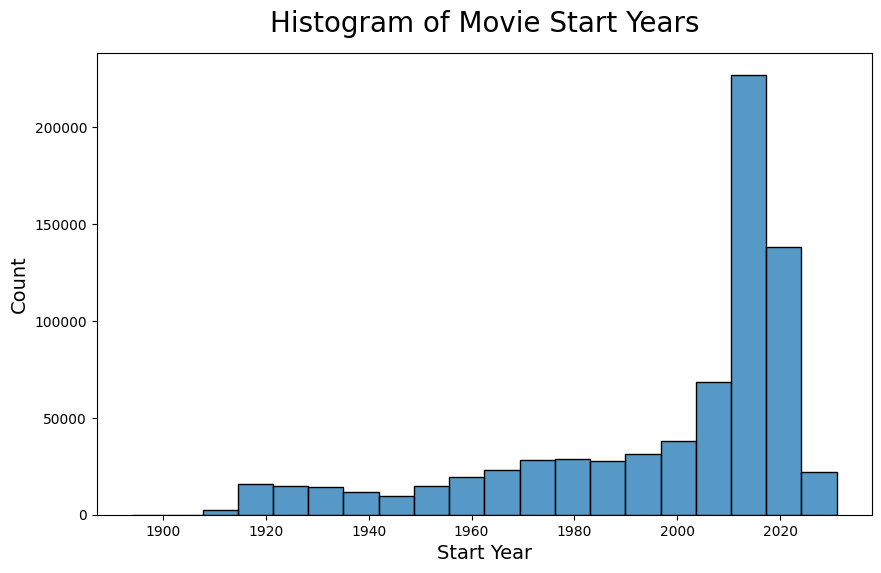

In [236]:
plt.figure(figsize=(10, 6))
plt.title("Histogram of Movie Start Years", fontsize=20, pad=15)
plt.xlabel("Start Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.histplot(data=data, x='startYear', bins=20)

plt.plot()

[]

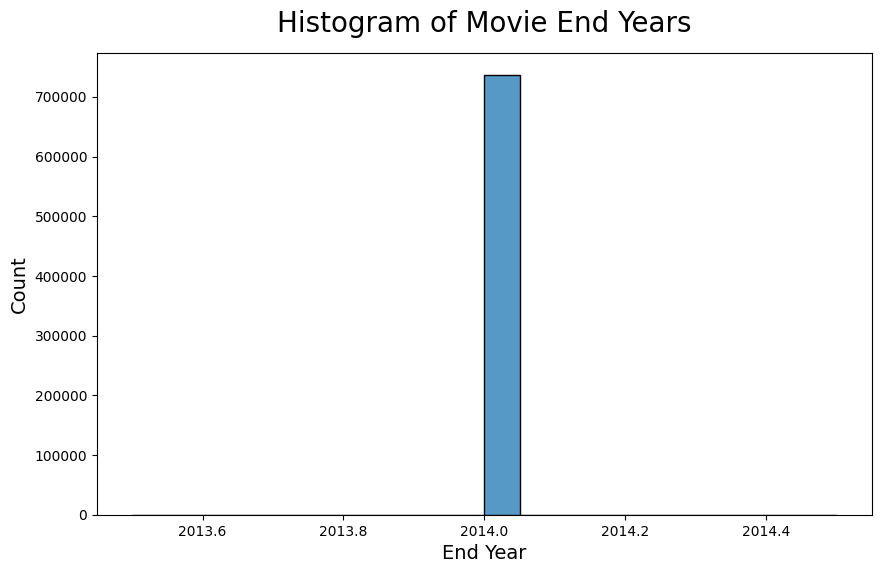

In [237]:
plt.figure(figsize=(10, 6))
plt.title("Histogram of Movie End Years", fontsize=20, pad=15)
plt.xlabel("End Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.histplot(data=data, x='endYear', bins=20)

plt.plot()

<p><b>Note:</b> Looks like endYears is a good column to drop.</p>

In [238]:
data = data.drop(columns='endYear')
data = data.rename(columns={'startYear': 'year'})

In [239]:
data.head()

,tconst,titleType,primaryTitle,originalTitle,year,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,1894,45,Romance,5.2,232.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,584.0
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,1900,40,"Biography,Drama",5.4,67.0
3,tt0000502,movie,Bohemios,Bohemios,1905,100,Unknown,3.1,26.0
4,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1047.0


In [240]:
def find_outliers_iqr(data):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = [i for i, x in enumerate(data) if x < lower_bound or x > upper_bound]
    
    print(f"Lower bound (Lower fence): {lower_bound}")
    print(f"Upper bound (Upper fence): {upper_bound}")
    
    return outliers

In [241]:
runTimeOutliersIndexes = find_outliers_iqr(data['runtimeMinutes'])
data.iloc[runTimeOutliersIndexes].sample(5)

Lower bound (Lower fence): -63.0
Upper bound (Upper fence): 185.0


,tconst,titleType,primaryTitle,originalTitle,year,runtimeMinutes,genres,averageRating,numVotes
77473,tt0111341,movie,Satantango,Sátántangó,1994,439,Drama,8.2,13858.0
392767,tt20123090,movie,You,You,2013,326,Drama,6.2,0.0
127613,tt0216330,movie,Uyira Manama,Uyira Manama,1968,188,Unknown,6.2,0.0
640195,tt5375100,movie,Paint Drying,Paint Drying,2016,607,Documentary,9.1,1560.0
210012,tt0479651,movie,Dasavatharam,Dasavatharam,2008,188,"Action,Adventure,Drama",7.3,11466.0


[]

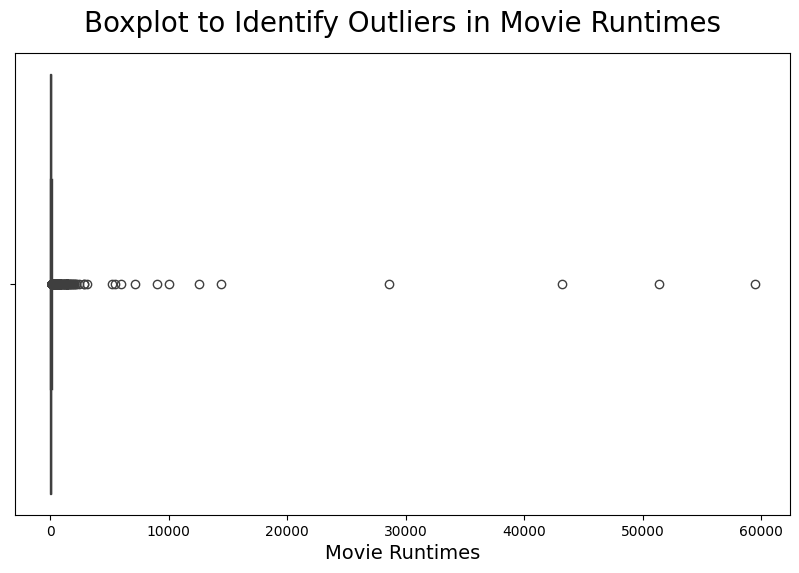

In [242]:
plt.figure(figsize=(10, 6))
plt.title("Boxplot to Identify Outliers in Movie Runtimes", fontsize=20, pad=15)
plt.xlabel("Movie Runtimes", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.boxplot(data=data, x="runtimeMinutes")
plt.plot()

In [243]:
# Dropped movies with really long runtime
data = data.query("runtimeMinutes < 300")

[]

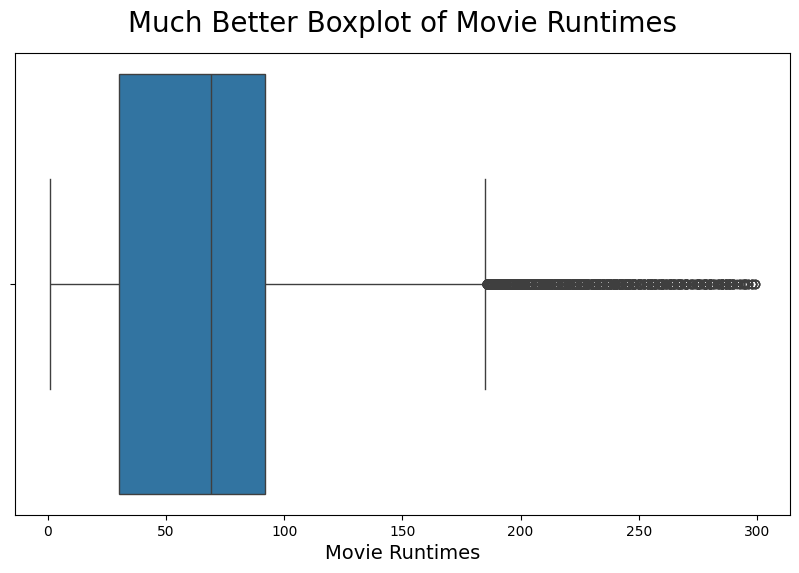

In [244]:
plt.figure(figsize=(10, 6))
plt.title("Much Better Boxplot of Movie Runtimes", fontsize=20, pad=15)
plt.xlabel("Movie Runtimes", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.boxplot(data=data, x="runtimeMinutes")
plt.plot()

[]

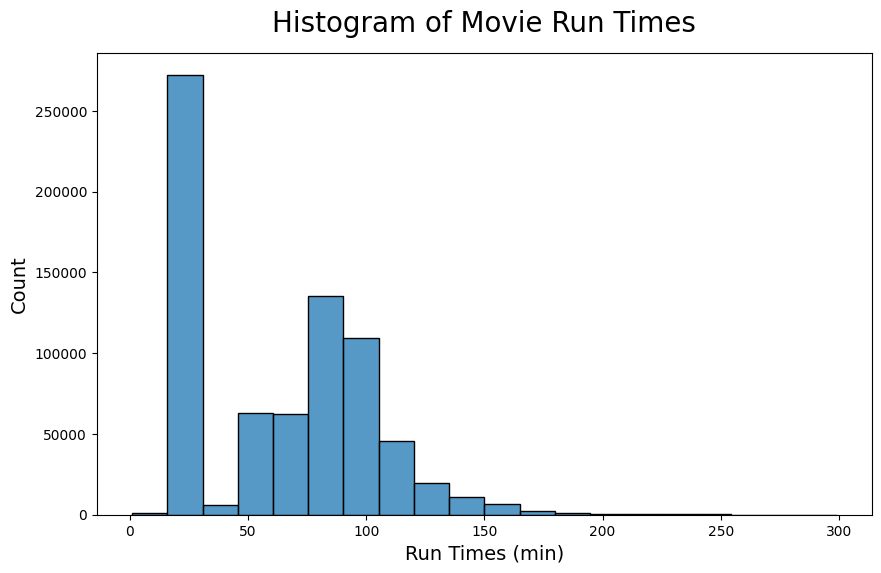

In [245]:
plt.figure(figsize=(10, 6))
plt.title("Histogram of Movie Run Times", fontsize=20, pad=15)
plt.xlabel("Run Times (min)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.histplot(data=data, x='runtimeMinutes', bins=20)

plt.plot()

[]

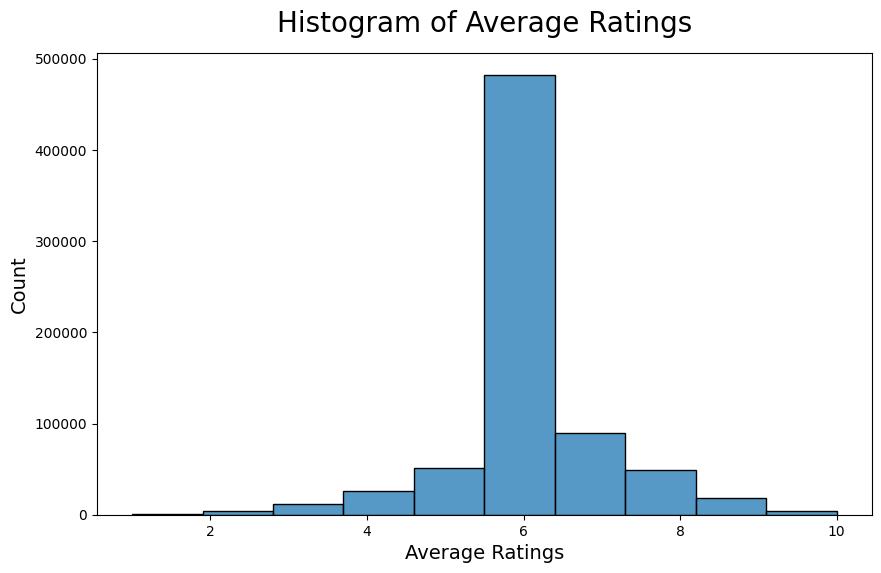

In [246]:
plt.figure(figsize=(10, 6))
plt.title("Histogram of Average Ratings", fontsize=20, pad=15)
plt.xlabel("Average Ratings", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.histplot(data=data, x='averageRating', bins=10)

plt.plot()

In [247]:
genres_dict = dict.fromkeys(genres, 0)

In [248]:
for genres_str in data['genres']:
    for genre in genres_str.split(','):
        genres_dict[genre] += 1

In [249]:
genres_dict

{'Horror': 45760,
 'Romance': 53010,
 'Family': 19750,
 'Documentary': 145135,
 'Drama': 269091,
 'Game-Show': 33,
 'Mystery': 20140,
 'Adult': 9223,
 'Western': 8039,
 'War': 10062,
 'Crime': 42592,
 'Adventure': 31414,
 'Biography': 19654,
 'Film-Noir': 877,
 'Reality-TV': 599,
 'Unknown': 77794,
 'History': 16392,
 'Animation': 11001,
 'News': 1496,
 'Sci-Fi': 16158,
 'Thriller': 52257,
 'Fantasy': 17879,
 'Music': 15099,
 'Talk-Show': 215,
 'Sport': 8738,
 'Comedy': 122737,
 'Short': 3,
 'Musical': 11149,
 'Action': 60752}

[]

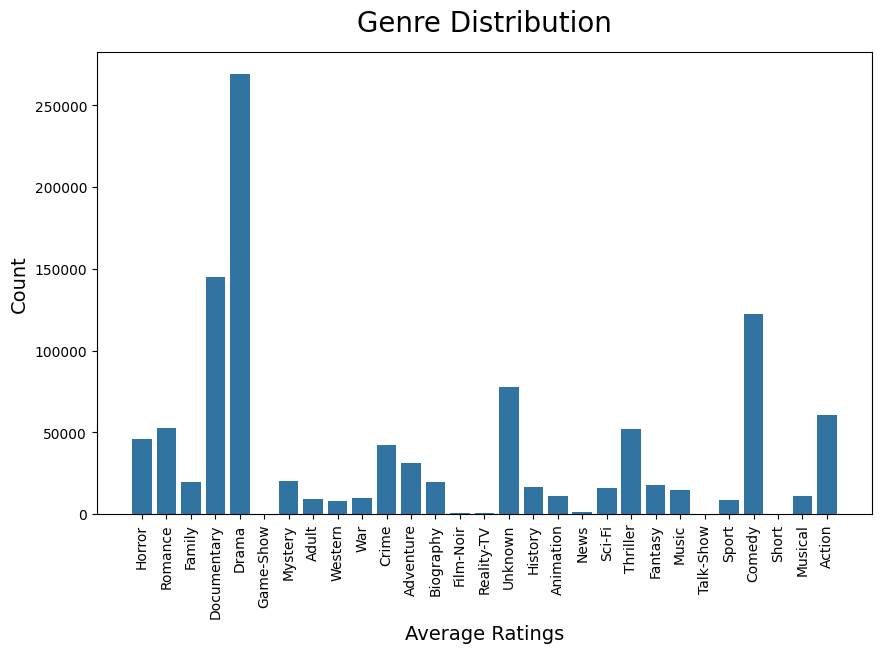

In [250]:
plt.figure(figsize=(10, 6))
plt.title("Genre Distribution", fontsize=20, pad=15)
plt.xlabel("Average Ratings", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
sns.barplot(x=genres_dict.keys(), y=genres_dict.values())

plt.plot()

In [251]:
print("Latest movie year: ", data['year'].max())
print("Earliest movie year: ", data['year'].min())

Latest movie year:  2031
Earliest movie year:  1894


In [252]:
data[data['year'] > 2026].sample(5)

,tconst,titleType,primaryTitle,originalTitle,year,runtimeMinutes,genres,averageRating,numVotes
545645,tt35050152,movie,Bluey: The Movie,Bluey: The Movie,2027,30,"Adventure,Animation,Comedy",6.2,0.0
407260,tt21361444,movie,Avengers: Secret Wars,Avengers: Secret Wars,2027,30,"Action,Adventure,Sci-Fi",6.2,0.0
588904,tt38681919,movie,Zac Power,Zac Power,2027,30,Drama,6.2,0.0
680527,tt7008874,movie,Margie Claus,Margie Claus,2027,30,"Animation,Comedy,Musical",6.2,0.0
447856,tt26443622,movie,Untitled Disney,Untitled Disney,2027,30,Unknown,6.2,0.0


In [257]:
data.query('primaryTitle != originalTitle and year > 2000').sample(5)

,tconst,titleType,primaryTitle,originalTitle,year,runtimeMinutes,genres,averageRating,numVotes
730021,tt9502538,movie,Caged Birds,Stürm: Bis wir tot sind oder frei,2020,118,"Crime,Drama,History",5.9,309.0
232211,tt10287954,movie,Rose Island,L'incredibile storia dell'isola delle rose,2020,117,"Adventure,Biography,Comedy",7.0,27321.0
165728,tt0313419,movie,Jazz War,Ocet,2001,30,"Documentary,Music",5.2,11.0
221403,tt0900381,movie,Trackman,Putevoy obkhodchik,2007,80,"Horror,Thriller",4.1,1040.0
238200,tt1051825,movie,Dementia,Junun,2006,104,"Drama,Horror",7.4,33.0


In [258]:
data = data.drop(columns='originalTitle')

In [259]:
data.head()

,tconst,titleType,primaryTitle,year,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,1894,45,Romance,5.2,232.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,1897,100,"Documentary,News,Sport",5.3,584.0
2,tt0000335,movie,Soldiers of the Cross,1900,40,"Biography,Drama",5.4,67.0
3,tt0000502,movie,Bohemios,1905,100,Unknown,3.1,26.0
4,tt0000574,movie,The Story of the Kelly Gang,1906,70,"Action,Adventure,Biography",6.0,1047.0


In [260]:
data.to_csv('/Users/christianmonsalve/Desktop/CODE/Projects/Movie_Recs/data/processed/explored_movies.csv', index=False)